<a href="https://colab.research.google.com/github/bodkhesakshi03-dotcom/Python_Libraries_Assignment_Solutions/blob/main/s_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("heart.csv")

# Display first 10 rows
print(df.head(10))

# Shape of dataset
print("Shape:", df.shape)

# Basic info
print(df.info())


   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

In [2]:
# Count of null values per column
print(df.isnull().sum())


Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [3]:
# Count duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

# New shape
print("New shape:", df.shape)


Duplicate rows: 0
New shape: (918, 12)


In [4]:
# Cholesterol = 0
chol_zero = (df['Cholesterol'] == 0).sum()
print("Rows with Cholesterol=0:", chol_zero)

# RestingBP = 0
bp_zero = (df['RestingBP'] == 0).sum()
print("Rows with RestingBP=0:", bp_zero)


Rows with Cholesterol=0: 172
Rows with RestingBP=0: 1


In [5]:
# Replace Cholesterol=0 with mean (excluding zeros)
chol_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = chol_mean

# Replace RestingBP=0 with mean (excluding zeros)
bp_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
df.loc[df['RestingBP'] == 0, 'RestingBP'] = bp_mean

# Round to 2 decimals
df['Cholesterol'] = df['Cholesterol'].round(2)
df['RestingBP'] = df['RestingBP'].round(2)

# Statistical summary before and after cleaning
print("After Cleaning:")
print(df[['Cholesterol','RestingBP']].describe())


After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


/tmp/ipykernel_730/661885597.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '244.6353887399464' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['Cholesterol'] == 0, 'Cholesterol'] = chol_mean
/tmp/ipykernel_730/661885597.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '132.54089422028352' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['RestingBP'] == 0, 'RestingBP'] = bp_mean


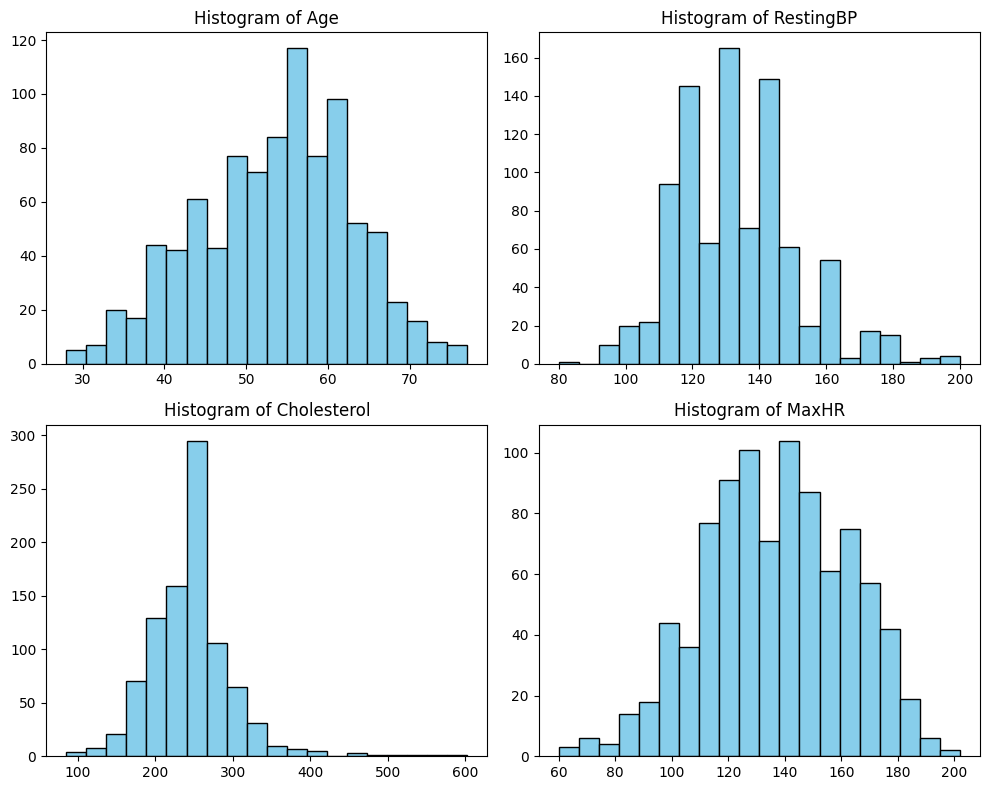

In [6]:
import matplotlib.pyplot as plt

def plot_histograms(data):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR']

    for i, col in enumerate(cols):
        ax = axes[i//2, i%2]
        ax.hist(data[col], bins=20, color='skyblue', edgecolor='black')
        ax.set_title(f'Histogram of {col}')

    plt.tight_layout()
    plt.show()

# Call function
plot_histograms(df)


In [7]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:", list(num_cols))
print("Categorical Columns:", list(cat_cols))


Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical Columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [8]:
df_encoded = pd.get_dummies(df, columns=cat_cols)

print("Encoded shape:", df_encoded.shape)
print(df_encoded.head())


Encoded shape: (918, 21)
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_LVH  RestingECG_Normal  Resti

In [9]:
print("Final shape:", df_encoded.shape)
print("Final columns:", df_encoded.columns.tolist())


Final shape: (918, 21)
Final columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [15]:
# Q10. Summary
# 1. Invalid values found and fixes:
#    - Many rows had Cholesterol = 0 and some had RestingBP = 0.
#    - These were replaced with the mean values of their respective columns (excluding zeros).
#    - Both columns were rounded to 2 decimal places.
#
# 2. Importance of handling invalid values:
#    - Values like Cholesterol = 0 are medically unrealistic.
#    - Keeping them would mislead statistical analysis and machine learning models.
#    - Cleaning ensures the dataset reflects real-world conditions.
#
# 3. Purpose of One-Hot Encoding:
#    - Converts categorical variables (like ChestPainType, RestingECG, ST_Slope) into numeric format.
#    - This allows machine learning algorithms to process categorical data effectively.
#
# 4. Other observations:
#    - Removing duplicates reduced redundancy in the dataset.
#    - Cleaning improved the reliability of statistical summaries.
#    - After encoding, the dataset expanded with new dummy columns but became fully numeric, ready for ML tasks.


